# Linear Actuator Speed Command Calibration

This notebook extracts the speed-vs-delay calibration data from `linear actuator speed calibration.xlsx` and creates a command equation for actuator delay as a function of desired speed.

The calibration sheet contains measured speed, command delay, and elapsed motion time. For a stepper-style actuator command, an inverse relationship is expected: lower delay should produce higher speed. First, the measured data is fit with

`speed = a / (delay + b) + c`

Then this equation is inverted so the controller can command delay from desired speed:

`delay = a / (speed - c) - b`

where `speed` is in the same units as the spreadsheet and `delay` is the command delay value from the calibration data.

In [1]:
from pathlib import Path

import numpy as np
from openpyxl import load_workbook
from scipy.optimize import curve_fit

workbook_path = Path("linear actuator speed calibration.xlsx")
if not workbook_path.exists():
    workbook_path = Path("hardware/linear actuator calibration/linear actuator speed calibration.xlsx")

sheet_name = "belt drive"

In [2]:
wb = load_workbook(workbook_path, data_only=True)
ws = wb[sheet_name]

headers = [cell.value for cell in ws[2]]
speed_col = headers.index("speed")
delay_col = headers.index("delay")
time_col = headers.index("ms")

rows = []
for row in ws.iter_rows(min_row=3, values_only=True):
    speed = row[speed_col]
    delay = row[delay_col]
    elapsed_ms = row[time_col]
    if isinstance(speed, (int, float)) and isinstance(delay, (int, float)):
        rows.append((float(delay), float(speed), float(elapsed_ms)))

data = np.array(rows, dtype=float)
data = data[np.argsort(data[:, 0])]

delay = data[:, 0]
speed = data[:, 1]
elapsed_ms = data[:, 2]

print(f"Loaded {len(data)} calibration points from {workbook_path.name!r} / {sheet_name!r}.")
print("\n delay    speed        elapsed_ms")
print("------  -----------  ----------")
for d, s, t in data:
    print(f"{d:6.0f}  {s:11.6f}  {t:10.0f}")

Loaded 28 calibration points from 'linear actuator speed calibration.xlsx' / 'belt drive'.

 delay    speed        elapsed_ms
------  -----------  ----------
   150   379.644588        1238
   160   356.330553        1319
   170   336.194564        1398
   180   317.782285        1479
   190   301.282051        1560
   200   286.410725        1641
   300   192.229039        2445
   400   144.615385        3250
   500   115.906289        4055
   600    96.707819        4860
   700    82.965578        5665
   800    72.665430        6468
   900    64.613693        7274
  1000    58.175517        8079
  1100    52.910053        8883
  1200    48.508618        9689
  1300    44.796035       10492
  1400    41.600283       11298
  1500    38.833347       12103
  1600    36.414349       12907
  1700    34.274047       13713
  1800    32.375835       14517
  1900    30.674847       15322
  2000    29.145479       16126
  2100    27.759731       16931
  2200    26.499774       17736
  2300    

In [3]:
def inverse_model(x, a, c):
    return a / x + c


def shifted_inverse_model(x, a, b, c):
    return a / (x + b) + c


def power_model(x, a, b):
    return a * x**b


def fit_model(name, model, p0):
    params, covariance = curve_fit(model, delay, speed, p0=p0, maxfev=100000)
    predicted = model(delay, *params)
    residuals = speed - predicted
    rmse = np.sqrt(np.mean(residuals**2))
    r2 = 1.0 - np.sum(residuals**2) / np.sum((speed - np.mean(speed))**2)
    return {
        "name": name,
        "model": model,
        "params": params,
        "covariance": covariance,
        "predicted": predicted,
        "residuals": residuals,
        "rmse": rmse,
        "r2": r2,
    }


fits = [
    fit_model("inverse", inverse_model, p0=[57000.0, 0.0]),
    fit_model("shifted inverse", shifted_inverse_model, p0=[58000.0, 4.0, 0.0]),
    fit_model("power law", power_model, p0=[54000.0, -1.0]),
]

for fit in fits:
    params = ", ".join(f"{p:.8g}" for p in fit["params"])
    print(f"{fit['name']:16s} params=[{params}]  RMSE={fit['rmse']:.6f}  R^2={fit['r2']:.10f}")

best_fit = min(fits, key=lambda item: item["rmse"])
print(f"\nBest fit by RMSE: {best_fit['name']}")

inverse          params=[56982.048, 1.0530018]  RMSE=0.558742  R^2=0.9999774735
shifted inverse  params=[58399.752, 3.8211675, -0.00022846421]  RMSE=0.057606  R^2=0.9999997606
power law        params=[53905.121, -0.98870989]  RMSE=0.269730  R^2=0.9999947504

Best fit by RMSE: shifted inverse


In [4]:
a, b, c = next(fit for fit in fits if fit["name"] == "shifted inverse")["params"]

print("Fit equation used for calibration:")
print(f"speed = {a:.8f} / (delay + {b:.8f}) + {c:.8f}")
print("\nRecommended command equation:")
print(f"delay = {a:.8f} / (speed - ({c:.8f})) - {b:.8f}")


def actuator_speed_from_delay(delay_value):
    return shifted_inverse_model(np.asarray(delay_value, dtype=float), a, b, c)


def actuator_delay_from_speed(speed_value):
    speed_value = np.asarray(speed_value, dtype=float)
    return a / (speed_value - c) - b


example_speeds = np.array([25, 40, 60, 100, 200, 300, 375], dtype=float)
example_delays = actuator_delay_from_speed(example_speeds)

print("\nExample predictions:")
for s, d in zip(example_speeds, example_delays):
    print(f"speed={s:8.3f} -> delay={d:10.3f}")

Fit equation used for calibration:
speed = 58399.75215056 / (delay + 3.82116746) + -0.00022846

Recommended command equation:
delay = 58399.75215056 / (speed - (-0.00022846)) - 3.82116746

Example predictions:
speed=  25.000 -> delay=  2332.148
speed=  40.000 -> delay=  1456.164
speed=  60.000 -> delay=   969.504
speed= 100.000 -> delay=   580.175
speed= 200.000 -> delay=   288.177
speed= 300.000 -> delay=   190.845
speed= 375.000 -> delay=   151.911


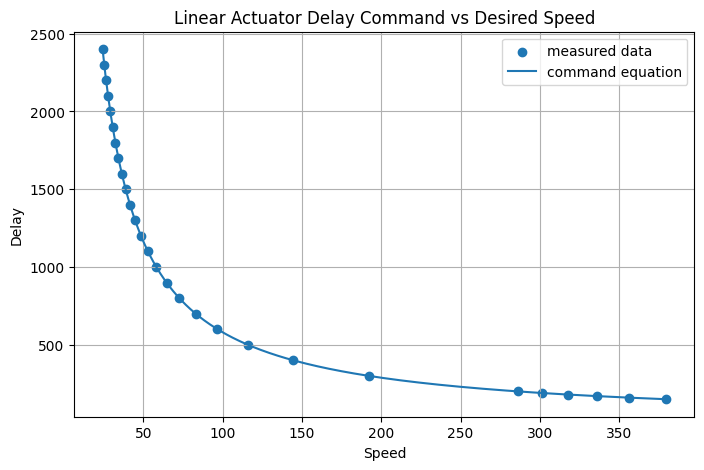

In [5]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

if plt is None:
    print("matplotlib is not installed. Install it to show the calibration plot.")
else:
    x_fit = np.linspace(speed.min(), speed.max(), 400)
    y_fit = actuator_delay_from_speed(x_fit)

    plt.figure(figsize=(8, 5))
    plt.scatter(speed, delay, label="measured data")
    plt.plot(x_fit, y_fit, label="command equation")
    plt.xlabel("Speed")
    plt.ylabel("Delay")
    plt.title("Linear Actuator Delay Command vs Desired Speed")
    plt.grid(True)
    plt.legend()
    plt.show()

In [6]:
predicted_delay = actuator_delay_from_speed(speed)
delay_residual = delay - predicted_delay
delay_rmse = np.sqrt(np.mean(delay_residual**2))

print(f"Delay RMSE from command equation: {delay_rmse:.6f}")
print("\nResiduals for delay command equation:")
print(" speed       measured_delay  predicted_delay  residual")
print("----------  --------------  ---------------  ----------")
for s, measured, predicted, residual in zip(speed, delay, predicted_delay, delay_residual):
    print(f"{s:10.6f}  {measured:14.3f}  {predicted:15.3f}  {residual:10.3f}")

Delay RMSE from command equation: 0.073194

Residuals for delay command equation:
 speed       measured_delay  predicted_delay  residual
----------  --------------  ---------------  ----------
379.644588         150.000          150.006      -0.006
356.330553         160.000          160.071      -0.071
336.194564         170.000          169.887       0.113
317.782285         180.000          179.952       0.048
301.282051         190.000          190.016      -0.016
286.410725         200.000          200.081      -0.081
192.229039         300.000          299.981       0.019
144.615385         400.000          400.006      -0.006
115.906289         500.000          500.031      -0.031
 96.707819         600.000          600.056      -0.056
 82.965578         700.000          700.080      -0.080
 72.665430         800.000          799.856       0.144
 64.613693         900.000          900.005      -0.005
 58.175517        1000.000         1000.029      -0.029
 52.910053        1100.

## Final Command Equation

Use this equation to convert a desired actuator speed into the command delay:

`delay = 58399.75215056 / (speed + 0.00022846) - 3.82116746`

Coefficient values:

- `a = 58399.75215056`
- `b = 3.82116746`
- `c = -0.00022846`

This comes from inverting the fitted calibration model:

`speed = a / (delay + b) + c`

so that:

`delay = a / (speed - c) - b`